In [1]:
from pathlib import Path

import tomllib

import numpy  as np
import tables as tb
import pandas as pd
import matplotlib.pyplot as plt

from nbtools import auto_plot_style
from nbtools import normhist
from nbtools import normhist2d
from jupyfun import progressbar

from utils import *

In [2]:
%matplotlib inline
auto_plot_style()

In [3]:
path      = Path("/home/gonzalo/data/COLINA/mc/colina/pitch_2mm_diam_2um/")
filenames = sorted(path.glob("*.h5"))
filename  = filenames[0]
len(filenames)

10

In [4]:
testdf = imgs_from_file(filename)
testdf

,x0,y0,z0,r0,image
event,,,,,
0,-13.329394,23.670591,-5.193839,27.165596,"[[[0, 0, 0, 0, 0, 0, 3, 2, 8, 0], [0, 0, 0, 0,..."
1,1.404493,-24.264316,-5.195832,24.304930,"[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0,..."
2,19.189315,-17.848769,-5.191469,26.207029,"[[[0, 0, 0, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0,..."
3,-28.293666,2.874758,-5.197838,28.439335,"[[[0, 1, 7, 11, 22, 26, 25, 8, 4, 0], [0, 0, 5..."
4,-13.254079,0.757871,-5.196730,13.275729,"[[[0, 0, 2, 9, 6, 6, 11, 1, 0, 0], [0, 0, 6, 5..."
...,...,...,...,...,...
49995,30.221348,-3.082523,-5.182230,30.378147,"[[[0, 0, 0, 0, 2, 0, 0, 0, 0, 0], [0, 0, 0, 0,..."
49996,23.973607,-12.130505,-5.177370,26.867880,"[[[0, 0, 0, 0, 1, 0, 2, 0, 0, 0], [0, 0, 0, 0,..."
49997,-27.235189,-12.370653,-5.178168,29.913017,"[[[3, 4, 21, 19, 22, 6, 3, 0, 0, 0], [2, 6, 19..."


In [5]:
config    = simconfig(filename)
sipm_pos  = sipm_positions(config.sipm_size, config.sipm_gap, config.n_sipm_side)[0]
sipm_x    = sipm_positions(config.sipm_size, config.sipm_gap, config.n_sipm_side)[1]
sipm_y    = sipm_positions(config.sipm_size, config.sipm_gap, config.n_sipm_side)[2]
sipm_x    = gang_array(sipm_x, 2, 2)/4
sipm_y    = gang_array(sipm_y, 2, 2)/4
extents   = sipm_extent   (config.sipm_size, config.sipm_gap, config.n_sipm_side)
ticks     = np.arange(-15, 16, 10) if config.el_diam==32 else np.arange(-30, 31, 15)

rmax   = config.el_diam/2
rbins  = np.linspace(    0, rmax, 81)
xybins = np.linspace(-rmax, rmax, 81)
drbins = np.linspace(    0, rmax, 81)

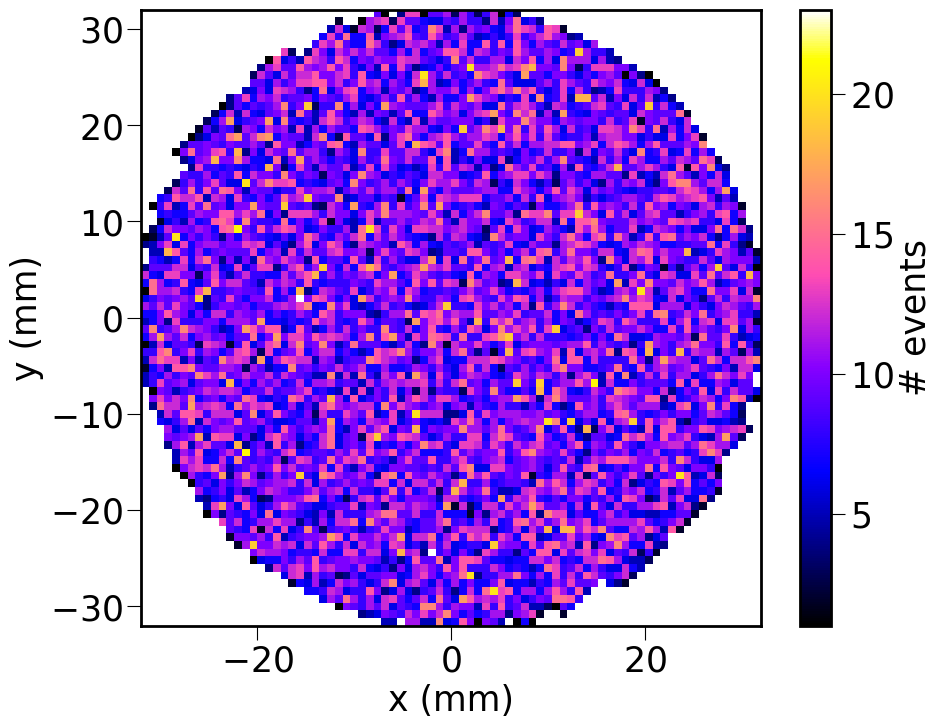

In [6]:
y = plt.hist2d(testdf.x0, testdf.y0, (xybins, xybins), cmin=1)[0]
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("# events")
evt_per_bin = y[y>0].mean()

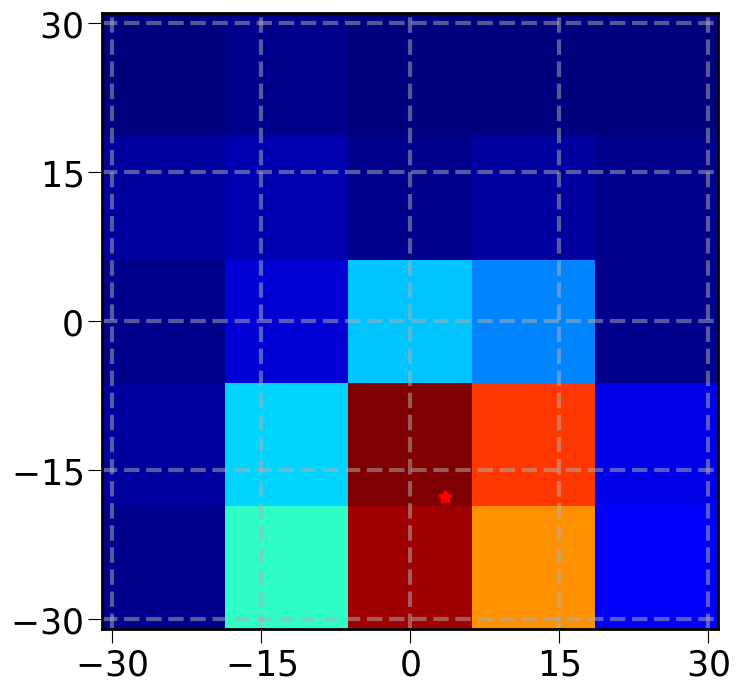

In [9]:
row = testdf.iloc[15:16]
row = gang_image(row, 2, 2).iloc[0]
img = row.image[0].T
x0  = row.x0
y0  = row.y0
plt.imshow(img, origin="lower", extent=extents, cmap="jet")
plt.scatter([x0], [y0], 50, marker="*", color="r")
plt.xticks(ticks)
plt.yticks(ticks)
plt.grid()

# Barycenter

In [10]:
df = testdf.groupby(level=0).apply(gang_image, 2, 2)
df = (df.groupby(level=0)
        .apply(barycenter, sipm_x, sipm_y)
        .join(df.drop(columns=["image"]))
     )
df.insert(df.shape[1], "dx", df.x - df.x0)
df.insert(df.shape[1], "dy", df.y - df.y0)
df.insert(df.shape[1], "dr", (df.dx**2 + df.dy**2)**0.5)

reco_bb = df

In [11]:
reco_bb

,,x,y,x0,y0,z0,r0,dx,dy,dr
event,event,,,,,,,,,
0,0,-11.611307,17.395053,-13.329394,23.670591,-5.193839,27.165596,1.718086,-6.275538,6.506473
1,1,3.051104,-18.697792,1.404493,-24.264316,-5.195832,24.304930,1.646611,5.566524,5.804957
2,2,15.796178,-14.848408,19.189315,-17.848769,-5.191469,26.207029,-3.393136,3.000362,4.529409
3,3,-19.352301,2.334728,-28.293666,2.874758,-5.197838,28.439335,8.941365,-0.540030,8.957658
4,4,-10.964211,-0.065263,-13.254079,0.757871,-5.196730,13.275729,2.289869,-0.823134,2.433320
...,...,...,...,...,...,...,...,...,...,...
49995,49995,18.758974,-1.960684,30.221348,-3.082523,-5.182230,30.378147,-11.462374,1.121840,11.517141
49996,49996,17.454777,-10.543949,23.973607,-12.130505,-5.177370,26.867880,-6.518830,1.586556,6.709121
49997,49997,-18.445000,-8.318333,-27.235189,-12.370653,-5.178168,29.913017,8.790189,4.052320,9.679294


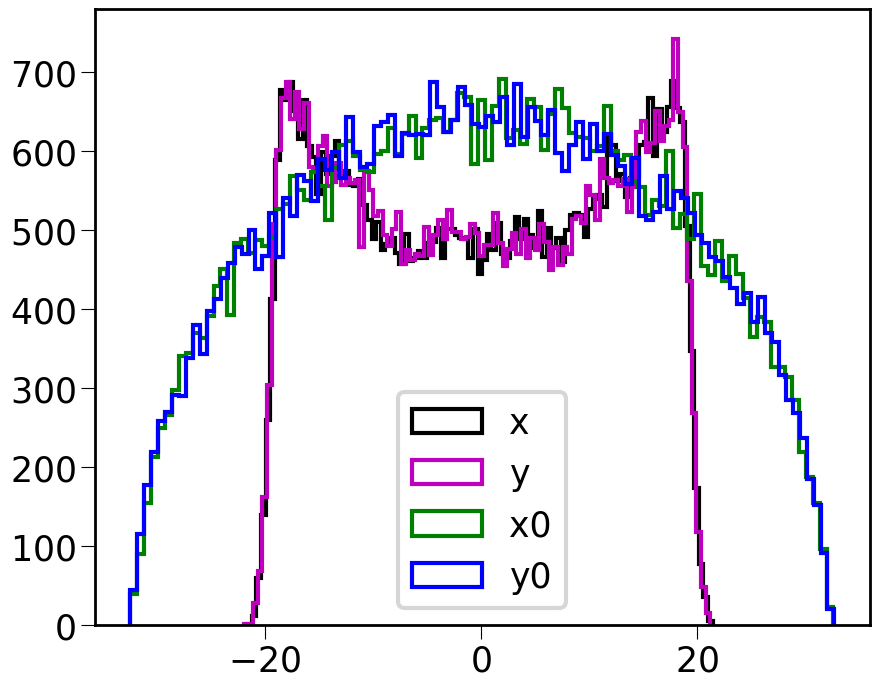

In [12]:
plt.hist(reco_bb.x , 101, histtype="step", label="x");
plt.hist(reco_bb.y , 101, histtype="step", label="y");
plt.hist(reco_bb.x0, 101, histtype="step", label="x0");
plt.hist(reco_bb.y0, 101, histtype="step", label="y0");
plt.legend()

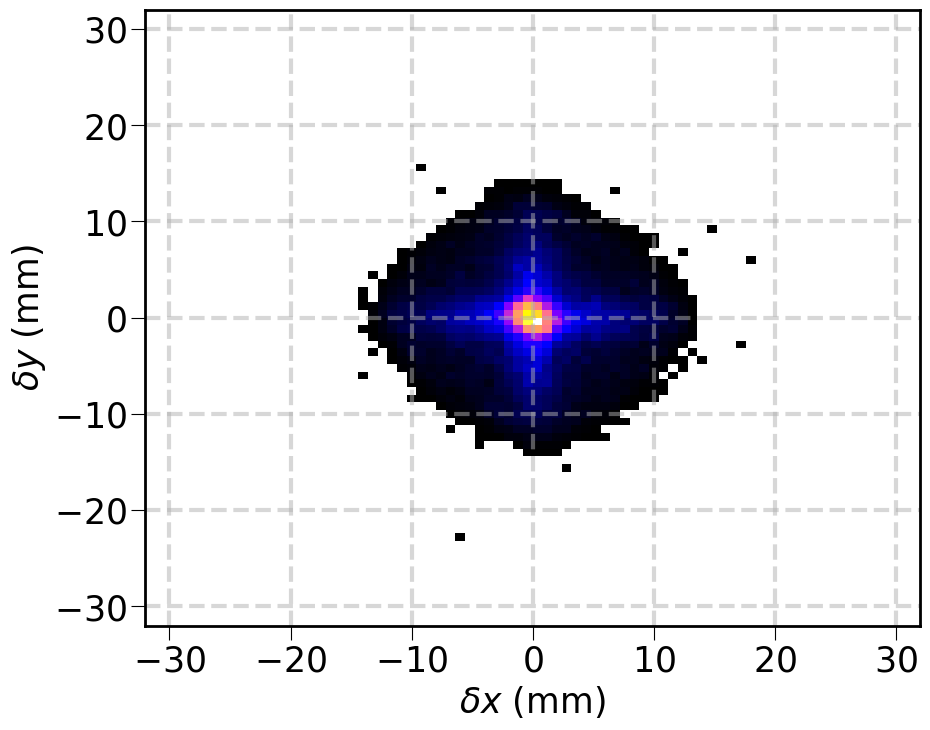

In [13]:
normhist2d(reco_bb.dx, reco_bb.dy, (drbins*2-drbins.max(),)*2)
plt.xlabel("$\delta x$ (mm)")
plt.ylabel("$\delta y$ (mm)")
plt.grid()

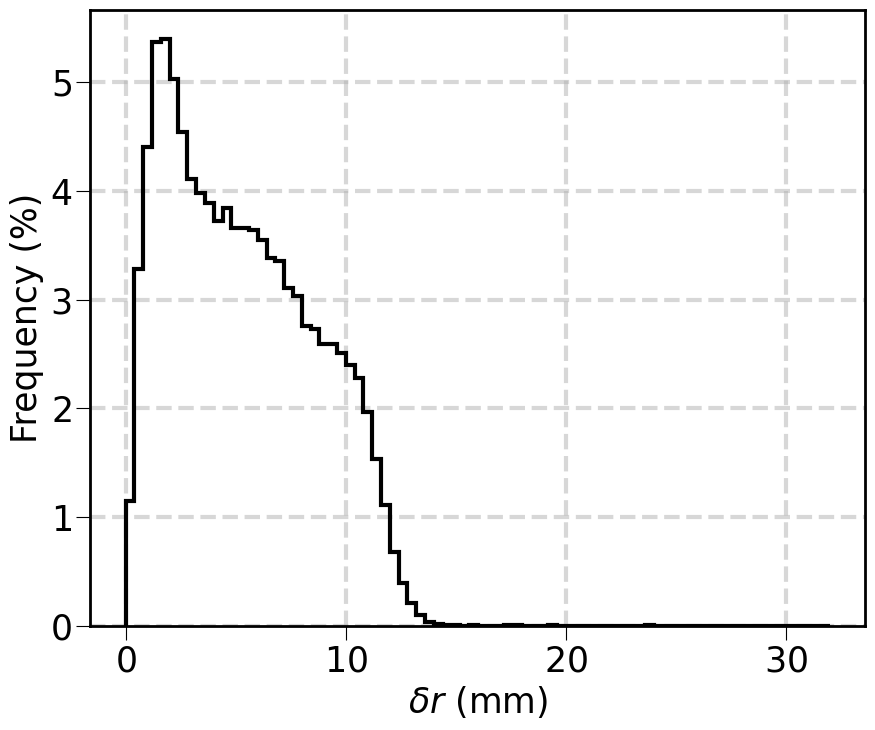

In [14]:
normhist(reco_bb.dr, drbins)
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.grid()

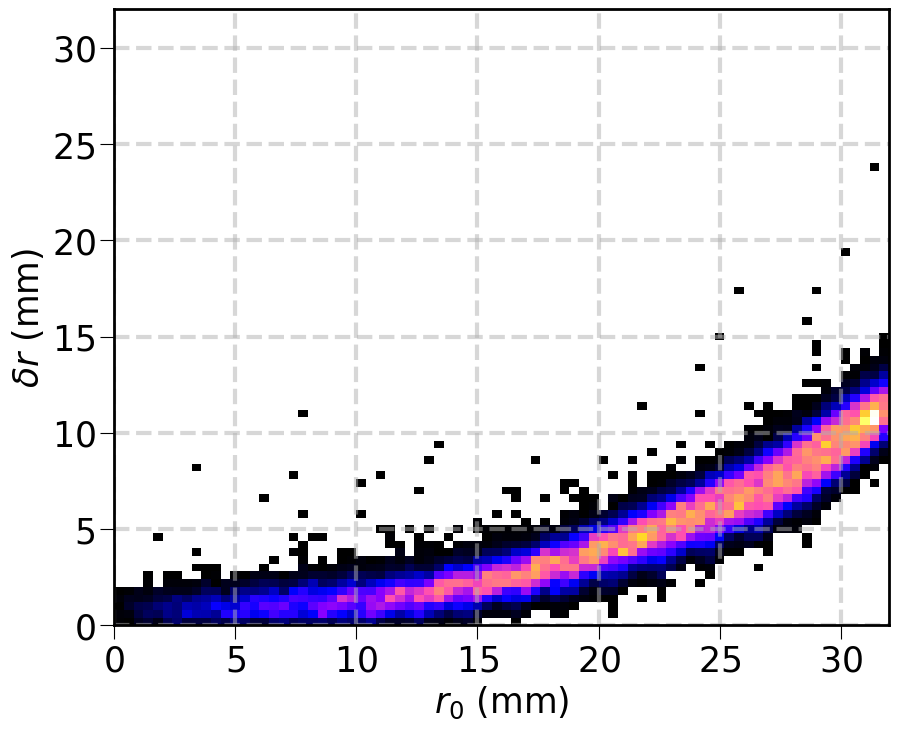

In [15]:
normhist2d(reco_bb.r0, reco_bb.dr, (rbins, drbins))
plt.xlabel("$r_0$ (mm)")
plt.ylabel("$\delta r$ (mm)")
plt.grid()

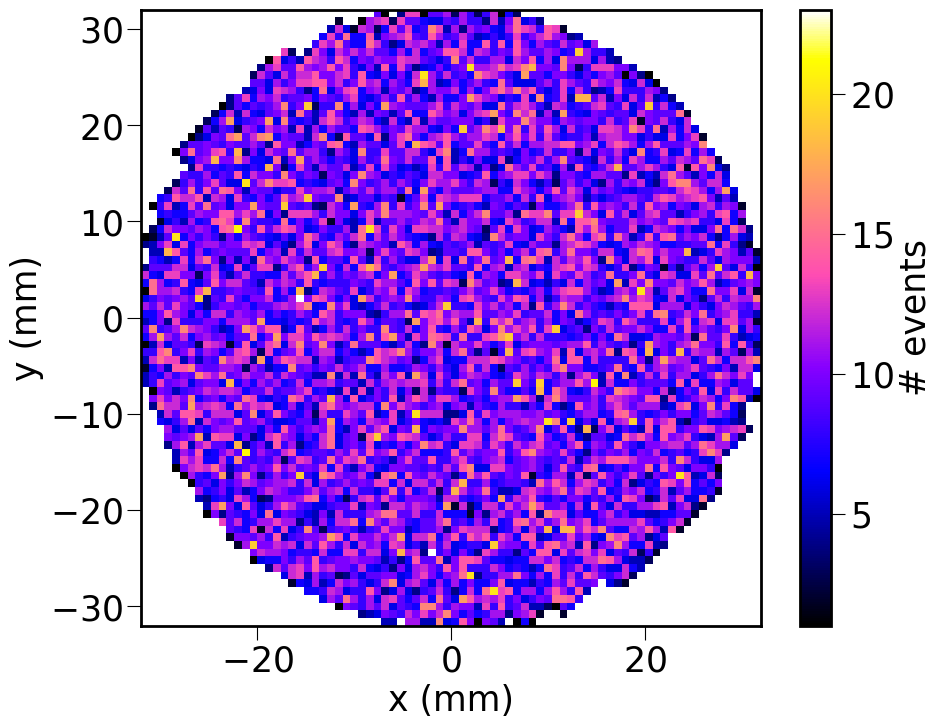

In [16]:
y = plt.hist2d(reco_bb.x0, reco_bb.y0, (xybins, xybins), cmin=1)[0]
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("# events")
evt_per_bin = y[y>0].mean()

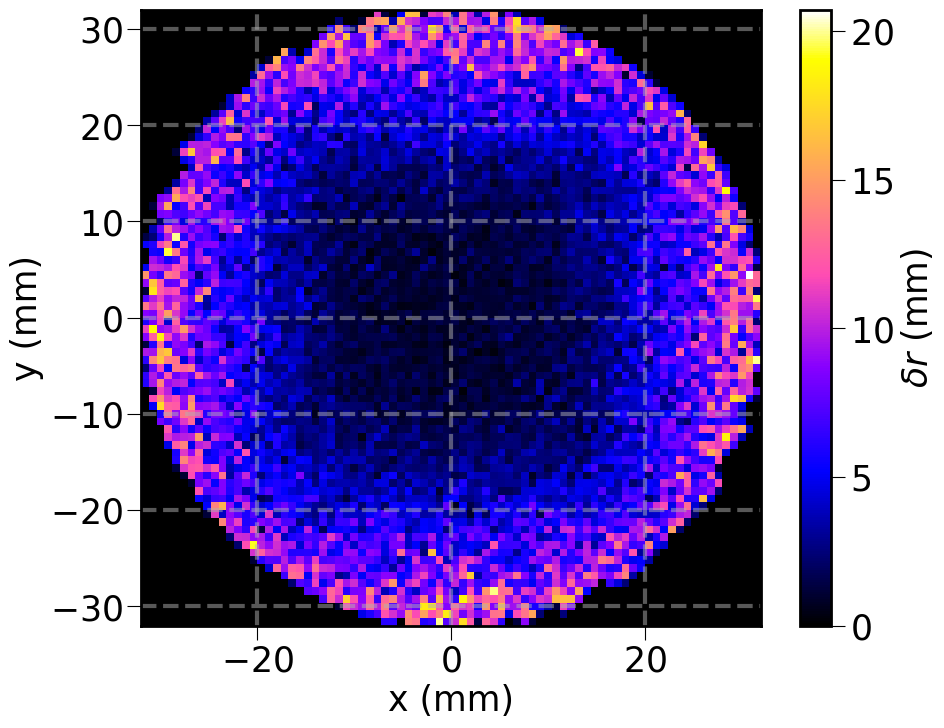

In [17]:
plt.hist2d(reco_bb.x0, reco_bb.y0, (xybins, xybins), weights=reco_bb.dr/evt_per_bin)
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("$\delta r$ (mm)")
plt.grid()

# NN

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim

In [19]:
class Linear(nn.Module):
    def __init__(self, nx, ny):
        super().__init__()
        self.flatten = nn.Flatten()
        self.l1      = nn.Linear(nx*ny, 64, dtype=float)
        self.l2      = nn.Linear(64, 32, dtype=float)
        self.l3      = nn.Linear(32, 2, dtype=float)
        
    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.l1(x))
        x = torch.relu(self.l2(x))
        x =            self.l3(x)
        return x

In [20]:
nfiles    = len(filenames)
train     = pd.concat([imgs_from_file(filename) for filename in filenames[:nfiles//2 ]]).reset_index().groupby(level=0).apply(gang_image, 2, 2)
test      = pd.concat([imgs_from_file(filename) for filename in filenames[ nfiles//2:]]).reset_index().groupby(level=0).apply(gang_image, 2, 2)
n_train   = len(train)
n_test    = len(test)
img_train = np.concatenate(train.image.values).astype(float)
img_test  = np.concatenate(test .image.values).astype(float)
pos_train = train.loc[:, "x0 y0".split()].values
pos_test  = test .loc[:, "x0 y0".split()].values

img_train = torch.tensor(img_train)
img_test  = torch.tensor(img_test )
pos_train = torch.tensor(pos_train)
pos_test  = torch.tensor(pos_test )

In [21]:
model     = Linear(config.n_sipm_side//2, config.n_sipm_side//2)
loss_f    = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [22]:
epochs = 500
batch_size = 32
batch_size = 1000

losses = []
for epoch in progressbar(range(epochs)):
    model.train()  # Set the model to training mode
    permutation = torch.randperm(img_train.size(0))  # Shuffle the dataset

    for i in range(0, img_train.size(0), batch_size):
        # Get the next batch
        indices = permutation[i:i + batch_size]
        imgs, pos = img_train[indices], pos_train[indices]

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = loss_f(outputs, pos)

        loss.backward()
        optimizer.step()
        losses.append(loss.detach().numpy())

Item 500 of 500 | 0.23 s/item | ETA 0.0 min | Ellapsed 1.9 min


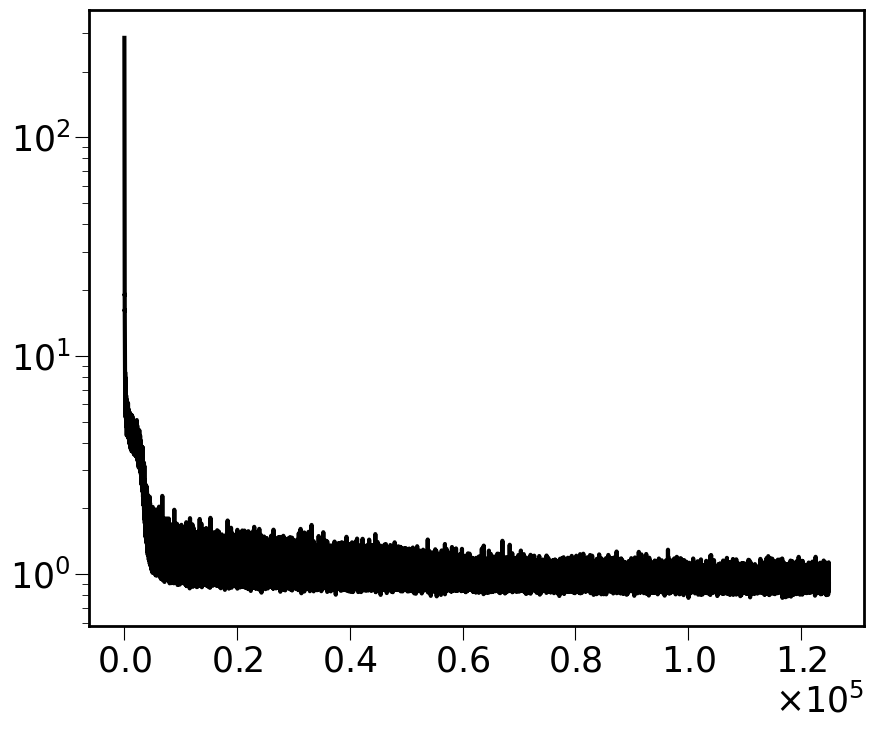

In [23]:
plt.plot(losses)
plt.yscale("log")
plt.show()

In [24]:
model.eval()  # Set the model to evaluation mode
pos_model = model(img_test).detach().numpy()
pos_test_ = pos_test.detach().numpy()

df = test.filter("x0 y0 r0".split())
df = df.assign(  x = pos_model.T[0]
              ,  y = pos_model.T[1]
              , dx = pos_model.T[0] - df.x0
              , dy = pos_model.T[1] - df.y0
              , dr = np.sum((pos_model - pos_test_)**2, axis=1)**0.5
              )

reco_nn = df

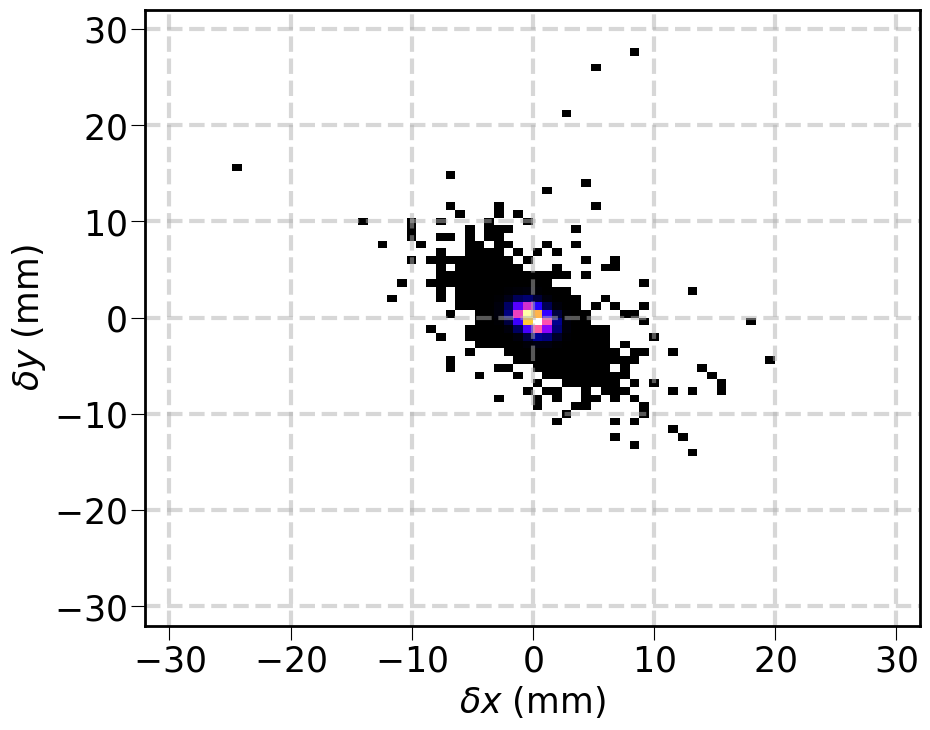

In [25]:
normhist2d(reco_nn.dx, reco_nn.dy, (drbins*2-drbins.max(),)*2)
plt.xlabel("$\delta x$ (mm)")
plt.ylabel("$\delta y$ (mm)")
plt.grid()

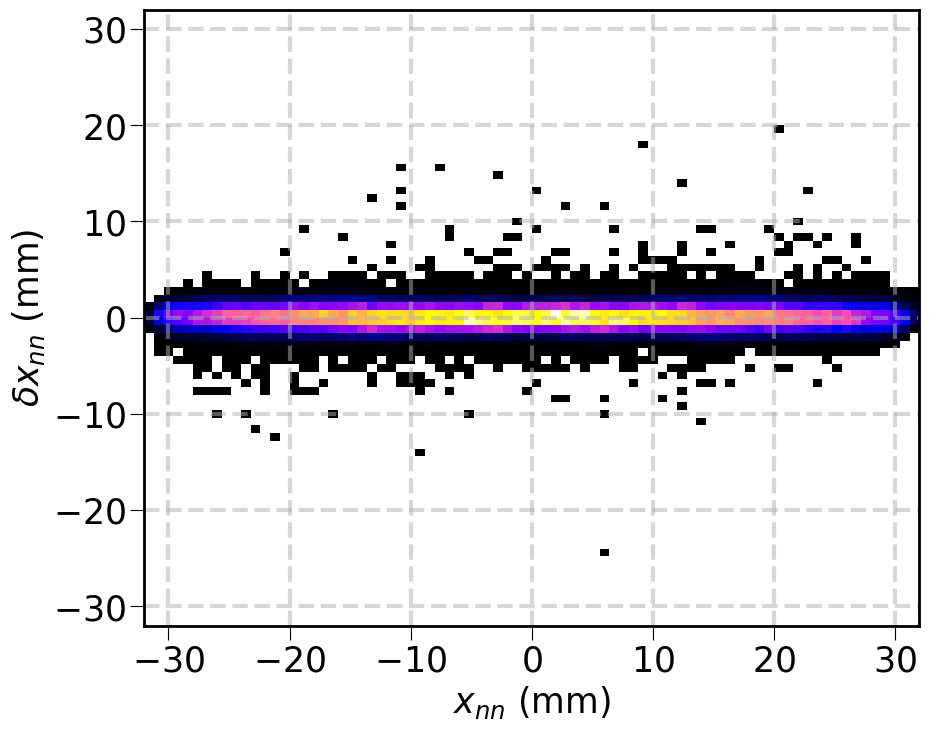

In [26]:
df = reco_nn
#df = df.loc[df.y.abs() < 1]
#df = df.loc[df.x>12]
normhist2d(df.x, df.dx, (xybins, xybins))
plt.xlabel("$x_{nn}$ (mm)")
plt.ylabel("$\delta x_{nn}$ (mm)")
plt.grid()

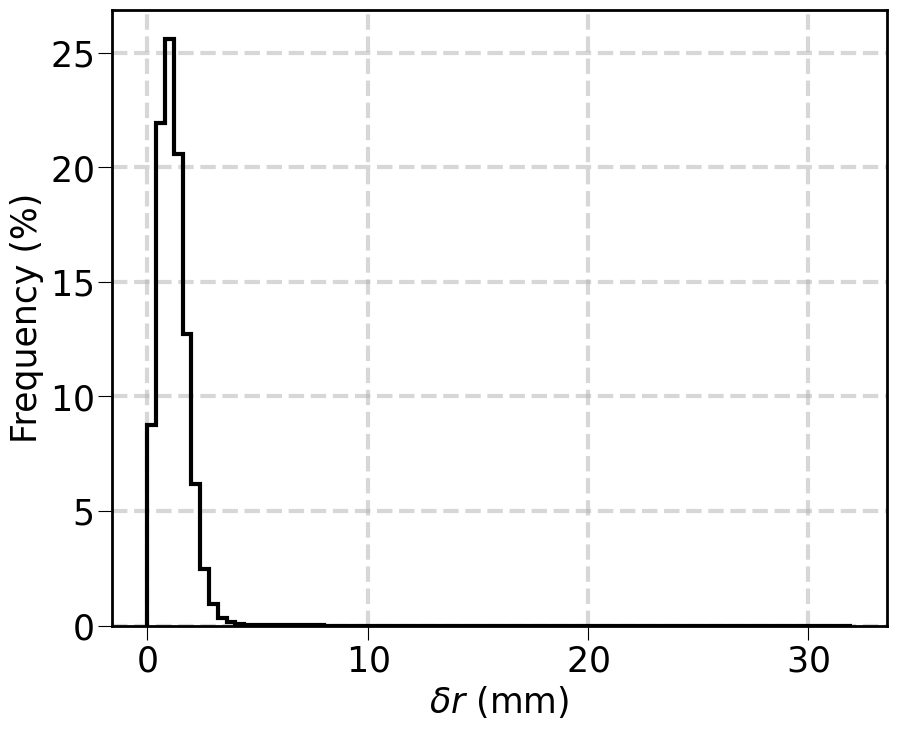

In [27]:
normhist(reco_nn.dr, drbins)
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.grid()
plt.show()

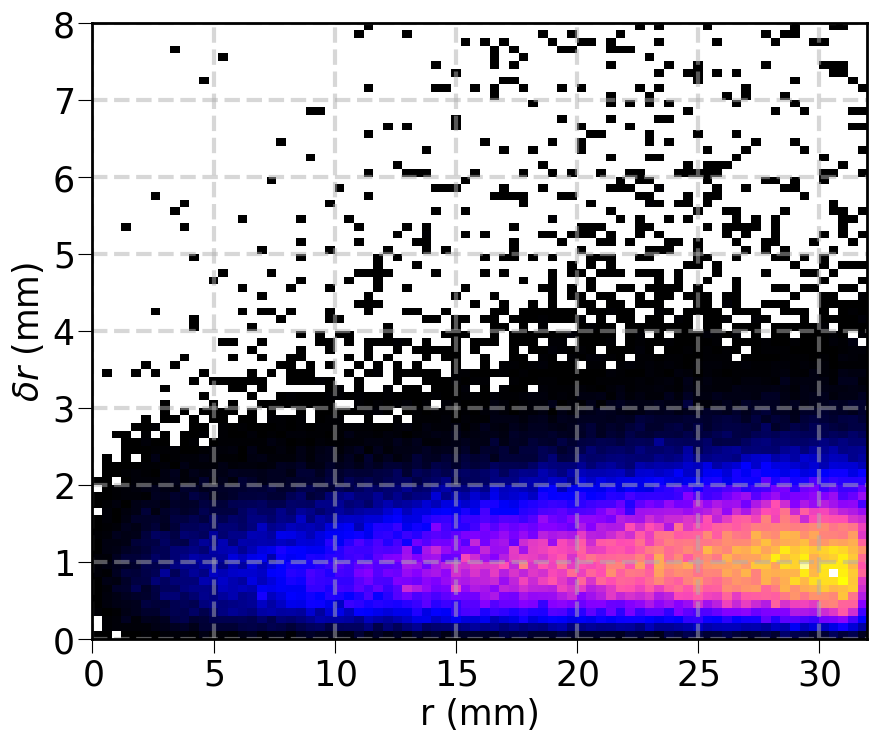

In [28]:
normhist2d(reco_nn.r0, reco_nn.dr, (rbins, drbins/4))
plt.xlabel("r (mm)")
plt.ylabel("$\delta r$ (mm)")
plt.grid()
plt.show()

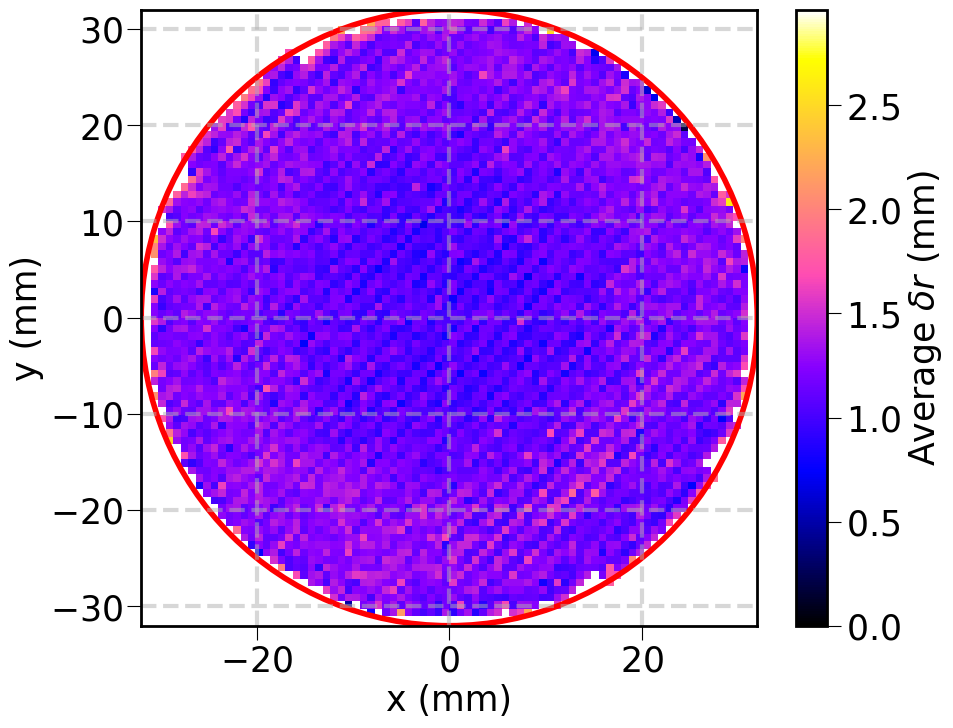

In [29]:
evts = np.histogram2d(reco_nn.x0, reco_nn.y0, (xybins, xybins))[0]
errs = np.histogram2d(reco_nn.x0, reco_nn.y0, (xybins, xybins), weights=reco_nn.dr)[0]
errs = errs / np.clip(evts, 1, None)
errs = np.where(errs>0, errs, np.nan)
plt.imshow(errs.T, origin="lower", vmin=0, vmax=2.5*np.median(errs[errs>0]), extent=extents)
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("Average $\delta r$ (mm)")
draw_el(plt.gca(), rmax)
plt.grid()

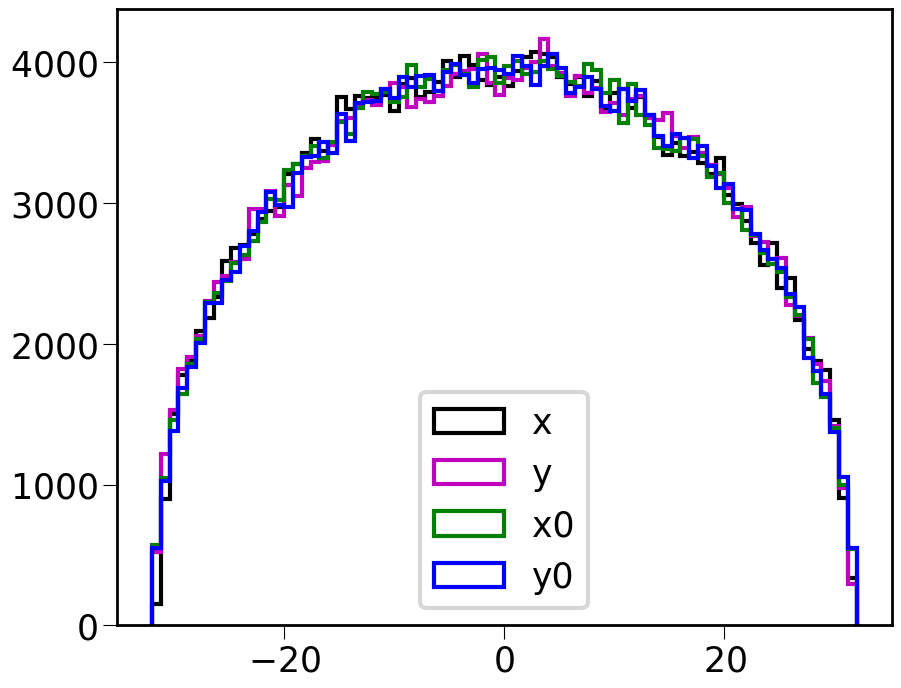

In [30]:
plt.hist(reco_nn.x , xybins, histtype="step", label="x");
plt.hist(reco_nn.y , xybins, histtype="step", label="y");
plt.hist(reco_nn.x0, xybins, histtype="step", label="x0");
plt.hist(reco_nn.y0, xybins, histtype="step", label="y0");
plt.legend()

In [31]:
reco_nn

,,x0,y0,r0,x,y,dx,dy,dr
0,0,7.804214,-7.343327,10.715886,8.956423,-7.513504,1.152209,-0.170176,1.164708
1,1,-10.011443,-14.220348,17.391012,-10.902610,-14.782182,-0.891167,-0.561834,1.053487
2,2,-4.618647,-31.631843,31.967255,-6.906007,-30.984833,-2.287361,0.647010,2.377108
3,3,26.172424,-1.011664,26.191969,27.149651,0.236700,0.977227,1.248364,1.585366
4,4,27.753311,-7.217760,28.676512,27.876713,-8.527844,0.123403,-1.310084,1.315883
...,...,...,...,...,...,...,...,...,...
249904,249904,0.070929,22.930092,22.930202,-0.459181,24.128297,-0.530111,1.198205,1.310234
249905,249905,21.815412,-3.502336,22.094763,22.417953,-2.916621,0.602541,0.585715,0.840308
249906,249906,-10.814159,-4.361996,11.660748,-12.415954,-3.349402,-1.601794,1.012594,1.895018
249907,249907,23.638565,-7.603545,24.831344,24.543165,-7.965196,0.904600,-0.361651,0.974214


In [32]:
output = filenames[0].parent
output = output.parent / (output.stem + "_ganging_reco_summary.h5")
reco_nn.to_hdf(output, key="/data", complib="zlib", complevel=4, mode="w")

In [33]:
import datetime
print(f"Last execution: {datetime.datetime.now()}")

Last execution: 2026-03-04 13:02:30.831707
